In [4]:

#importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleaanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [5]:
date_counts = df.job_posted_date.value_counts()
date_counts = date_counts.sort_index()

In [6]:
date_counts

job_posted_date
2023-01-01 00:00:04    1
2023-01-01 00:00:07    1
2023-01-01 00:00:22    1
2023-01-01 00:00:24    1
2023-01-01 00:00:27    1
                      ..
2023-12-31 23:40:18    2
2023-12-31 23:40:22    2
2023-12-31 23:40:31    2
2023-12-31 23:40:32    1
2023-12-31 23:59:58    2
Name: count, Length: 607192, dtype: int64

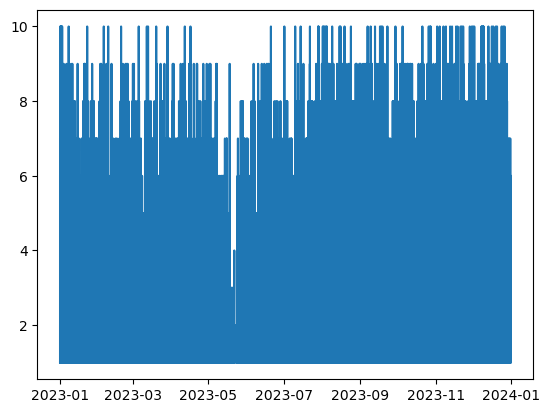

In [7]:
plt.plot(date_counts.index , date_counts)

In [8]:
df['job_posted_month'] = df['job_posted_date'].dt.month

In [9]:
monthly_counts = df['job_posted_month'].value_counts()
monthly_counts = monthly_counts.sort_index()
monthly_counts

job_posted_month
1     91822
2     64578
3     64084
4     62919
5     52104
6     61572
7     63777
8     75162
9     62359
10    66611
11    64450
12    56303
Name: count, dtype: int64

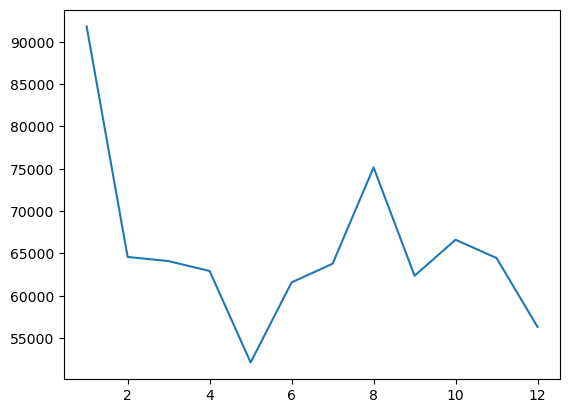

In [10]:
plt.plot(monthly_counts.index, monthly_counts)

In [11]:
job_counts = df.job_title_short.value_counts()

<BarContainer object of 10 artists>

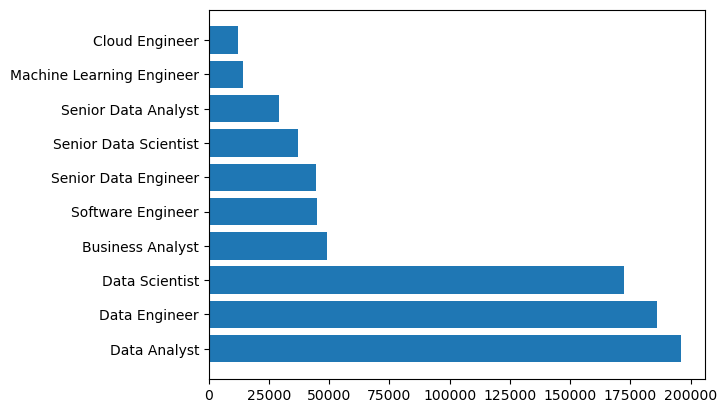

In [12]:
plt.barh(job_counts.index, job_counts)

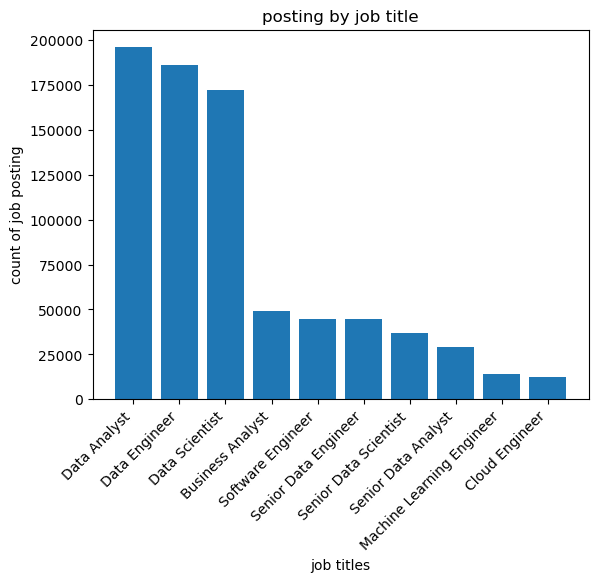

In [13]:
plt.bar(job_counts.index, job_counts)
plt.title('posting by job title')
plt.ylabel('count of job posting')
plt.xlabel('job titles')
plt.xticks(rotation=45, ha='right')
plt.show()

<Axes: xlabel='job_title_short'>

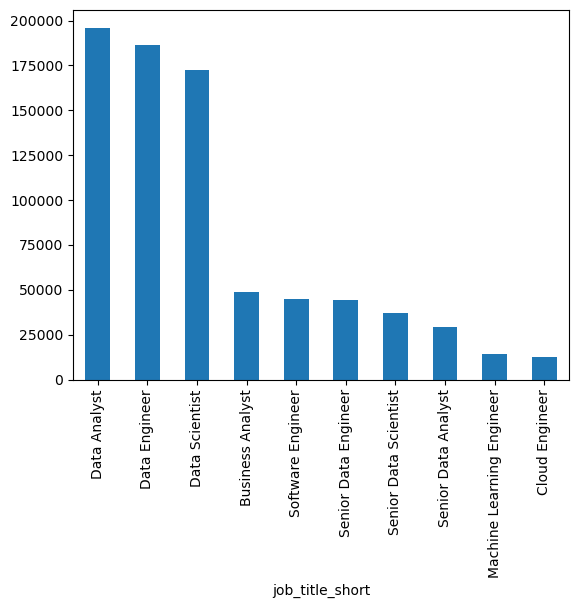

In [14]:
job_counts.plot(kind='bar')

In [15]:
job_salary = df.groupby('job_title_short')['salary_year_avg'].median().sort_values()

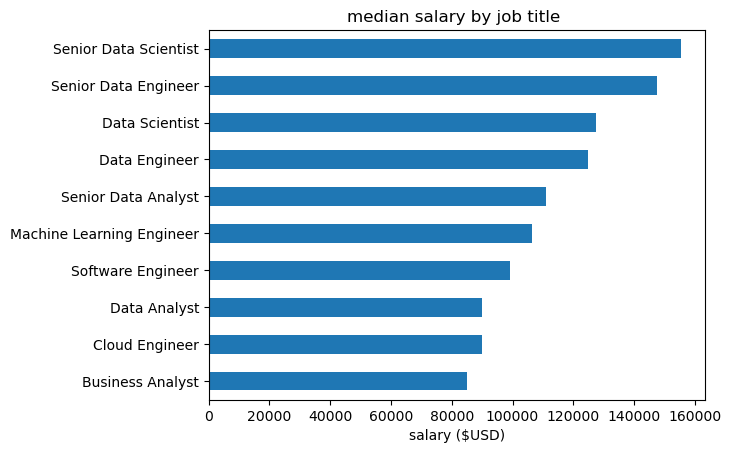

In [16]:
job_salary.plot(kind='barh')
plt.xlabel('salary ($USD)')
plt.ylabel('')
plt.title('median salary by job title ')
plt.show()